<a href="https://www.kaggle.com/code/sonawanelalitsunil/airline-report-fy-2022-23-ml-100?scriptVersionId=249164512" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airlinedataset/airline_data.csv


## Title:
Airline Performance Report FY 2022/23

## Description:
A detailed analysis of airline operational and financial performance for the fiscal year 2022/23. The report includes metrics such as passenger traffic, on-time performance, load factors, revenue, and cost trends across major carriers, highlighting key improvements, challenges, and year-over-year comparisons.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/airlinedataset/airline_data.csv')

In [3]:
df.head()

,iata_code,airline_name,region,functional_currency,ebit_usd,load_factor,low_cost_carrier,airline_age,num_routes,passenger_yield,ask,avg_fleet_age,fleet_size,aircraft_utilisation
0,ET,Ethiopian Airlines,Africa,ETB,1.032027e+09,0.703,N,78.0,136.0,0.107,6.449871e+10,8.80,154.0,NaN
1,KQ,Kenya Airways,Africa,KES,7.600000e+07,0.784,N,47.0,42.0,0.111,1.480400e+10,13.50,40.0,NaN
2,LA,LATAM Airlines,Latin America,USD,1.078165e+09,0.831,N,95.0,148.0,0.090,1.370000e+11,11.48,333.0,NaN
3,AV,Avianca,Latin America,USD,6.185440e+08,0.824,N,104.0,147.0,0.083,5.470600e+10,9.30,140.0,NaN
4,AD,Azul Brazilian Airlines,Latin America,BRL,5.968403e+08,0.804,Y,15.0,160.0,0.101,4.400600e+10,7.40,183.0,10.0


In [4]:
df.tail()

,iata_code,airline_name,region,functional_currency,ebit_usd,load_factor,low_cost_carrier,airline_age,num_routes,passenger_yield,ask,avg_fleet_age,fleet_size,aircraft_utilisation
95,9C,Spring Airlines,Asia Pacific,CNY,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,SU,Aeroflot,Asia Pacific,RUB,2.036990e+09,0.875,N,101.0,216.0,0.110,1.410000e+11,8.9,349.0,NaN
97,NH,ANA,Asia Pacific,JPY,8.988990e+08,0.736,N,72.0,195.0,0.123,8.577600e+10,NaN,268.0,NaN
98,NQ,Air Japan,Asia Pacific,JPY,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,UO,HK Express,Asia Pacific,HKD,NaN,NaN,Y,NaN,NaN,NaN,NaN,7.1,33.0,NaN


In [5]:
df.shape

(100, 14)

In [6]:
df.dtypes

iata_code                object
airline_name             object
region                   object
functional_currency      object
ebit_usd                float64
load_factor             float64
low_cost_carrier         object
airline_age             float64
num_routes              float64
passenger_yield         float64
ask                     float64
avg_fleet_age           float64
fleet_size              float64
aircraft_utilisation    float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   iata_code             100 non-null    object 
 1   airline_name          100 non-null    object 
 2   region                100 non-null    object 
 3   functional_currency   100 non-null    object 
 4   ebit_usd              70 non-null     float64
 5   load_factor           70 non-null     float64
 6   low_cost_carrier      100 non-null    object 
 7   airline_age           71 non-null     float64
 8   num_routes            54 non-null     float64
 9   passenger_yield       58 non-null     float64
 10  ask                   66 non-null     float64
 11  avg_fleet_age         64 non-null     float64
 12  fleet_size            72 non-null     float64
 13  aircraft_utilisation  21 non-null     float64
dtypes: float64(9), object(5)
memory usage: 11.1+ KB


In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

iata_code                0
airline_name             0
region                   0
functional_currency      0
ebit_usd                30
load_factor             30
low_cost_carrier         0
airline_age             29
num_routes              46
passenger_yield         42
ask                     34
avg_fleet_age           36
fleet_size              28
aircraft_utilisation    79
dtype: int64

In [10]:
df.describe()

,ebit_usd,load_factor,airline_age,num_routes,passenger_yield,ask,avg_fleet_age,fleet_size,aircraft_utilisation
count,7.000000e+01,70.000000,71.000000,54.000000,58.000000,6.600000e+01,64.000000,72.000000,21.000000
mean,7.918721e+08,0.814914,50.605634,254.555556,0.091069,9.913715e+10,10.042656,220.402778,10.060476
std,1.199401e+09,0.054593,29.405286,259.295684,0.026287,1.107934e+11,3.994612,251.109687,2.425425
min,-4.957570e+08,0.628000,3.000000,25.000000,0.030000,9.030040e+08,3.000000,10.000000,6.200000
25%,7.915575e+07,0.790500,28.000000,101.000000,0.078750,3.171090e+10,7.075000,74.500000,8.140000
50%,3.344298e+08,0.827500,40.000000,160.000000,0.092000,5.501650e+10,9.350000,123.000000,10.000000
75%,1.066630e+09,0.850000,77.000000,300.000000,0.107750,1.141028e+11,12.100000,272.000000,11.400000
max,5.521000e+09,0.930000,105.000000,1100.000000,0.160000,4.688550e+11,21.000000,965.000000,16.000000


In [11]:
df.columns

Index(['iata_code', 'airline_name', 'region', 'functional_currency',
       'ebit_usd', 'load_factor', 'low_cost_carrier', 'airline_age',
       'num_routes', 'passenger_yield', 'ask', 'avg_fleet_age', 'fleet_size',
       'aircraft_utilisation'],
      dtype='object')

## Data visualizations

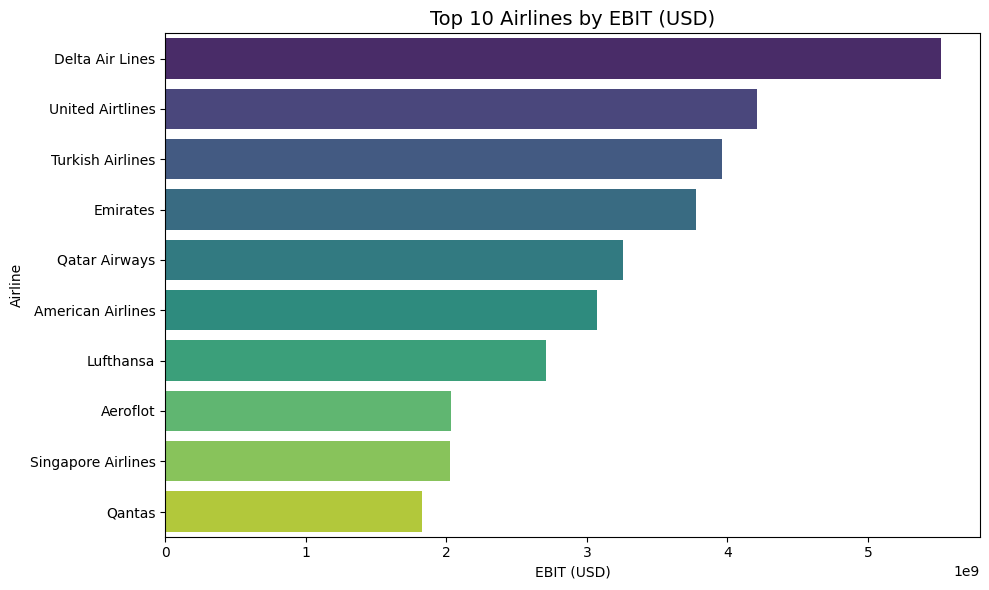

In [12]:
top_ebit = df.nlargest(10, 'ebit_usd')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_ebit, x='ebit_usd', y='airline_name', palette='viridis')
plt.title("Top 10 Airlines by EBIT (USD)", fontsize=14)
plt.xlabel("EBIT (USD)")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()


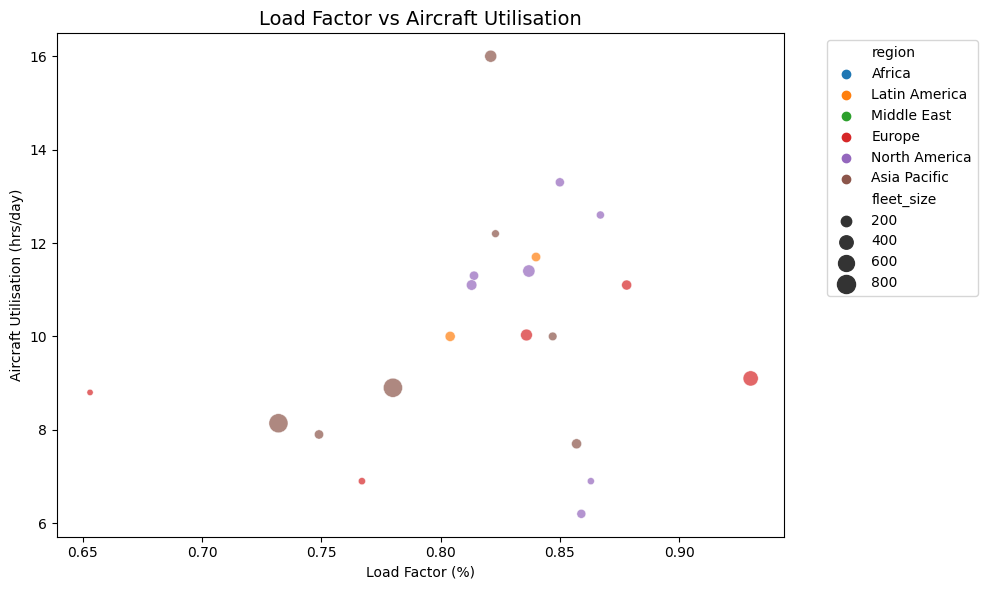

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='load_factor', y='aircraft_utilisation',
                hue='region', size='fleet_size', sizes=(20, 200), alpha=0.7)
plt.title("Load Factor vs Aircraft Utilisation", fontsize=14)
plt.xlabel("Load Factor (%)")
plt.ylabel("Aircraft Utilisation (hrs/day)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


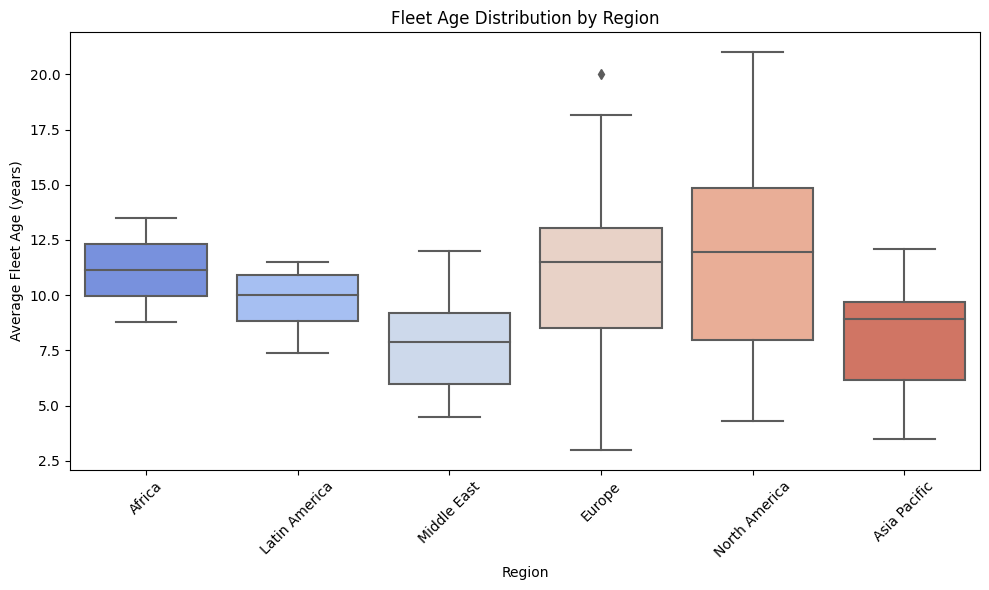

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='avg_fleet_age', palette='coolwarm')
plt.title("Fleet Age Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Average Fleet Age (years)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


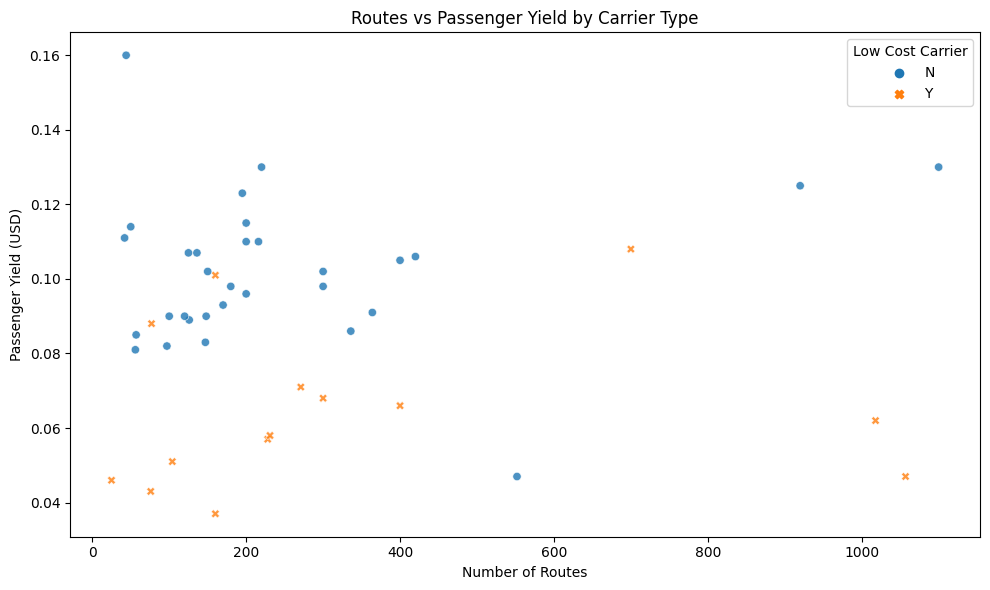

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='num_routes', y='passenger_yield',
                hue='low_cost_carrier', style='low_cost_carrier', alpha=0.8)
plt.title("Routes vs Passenger Yield by Carrier Type")
plt.xlabel("Number of Routes")
plt.ylabel("Passenger Yield (USD)")
plt.legend(title='Low Cost Carrier')
plt.tight_layout()
plt.show()


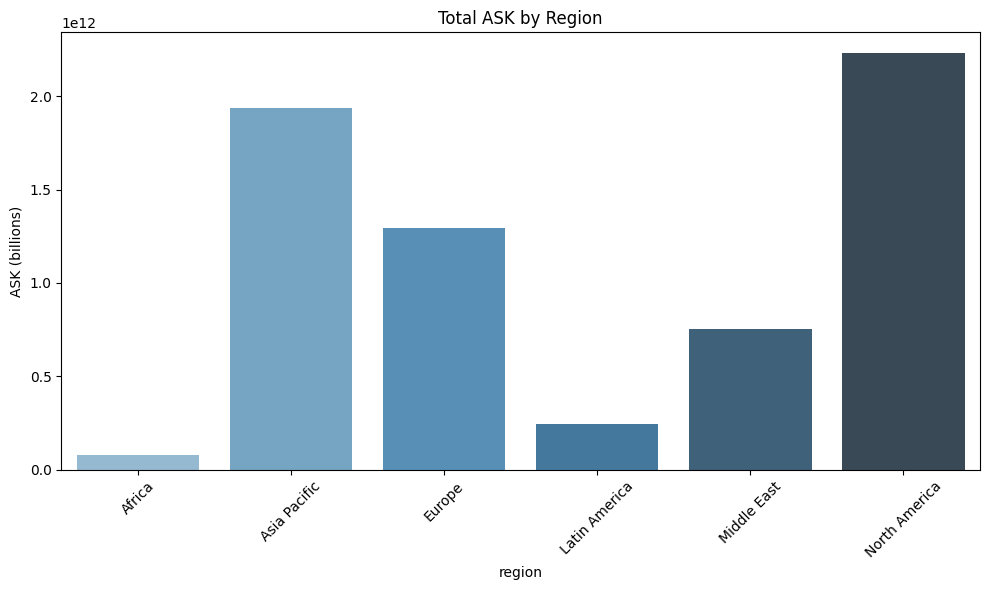

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df.groupby('region', as_index=False)['ask'].sum(), 
            x='region', y='ask', palette='Blues_d')
plt.title("Total ASK by Region")
plt.ylabel("ASK (billions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


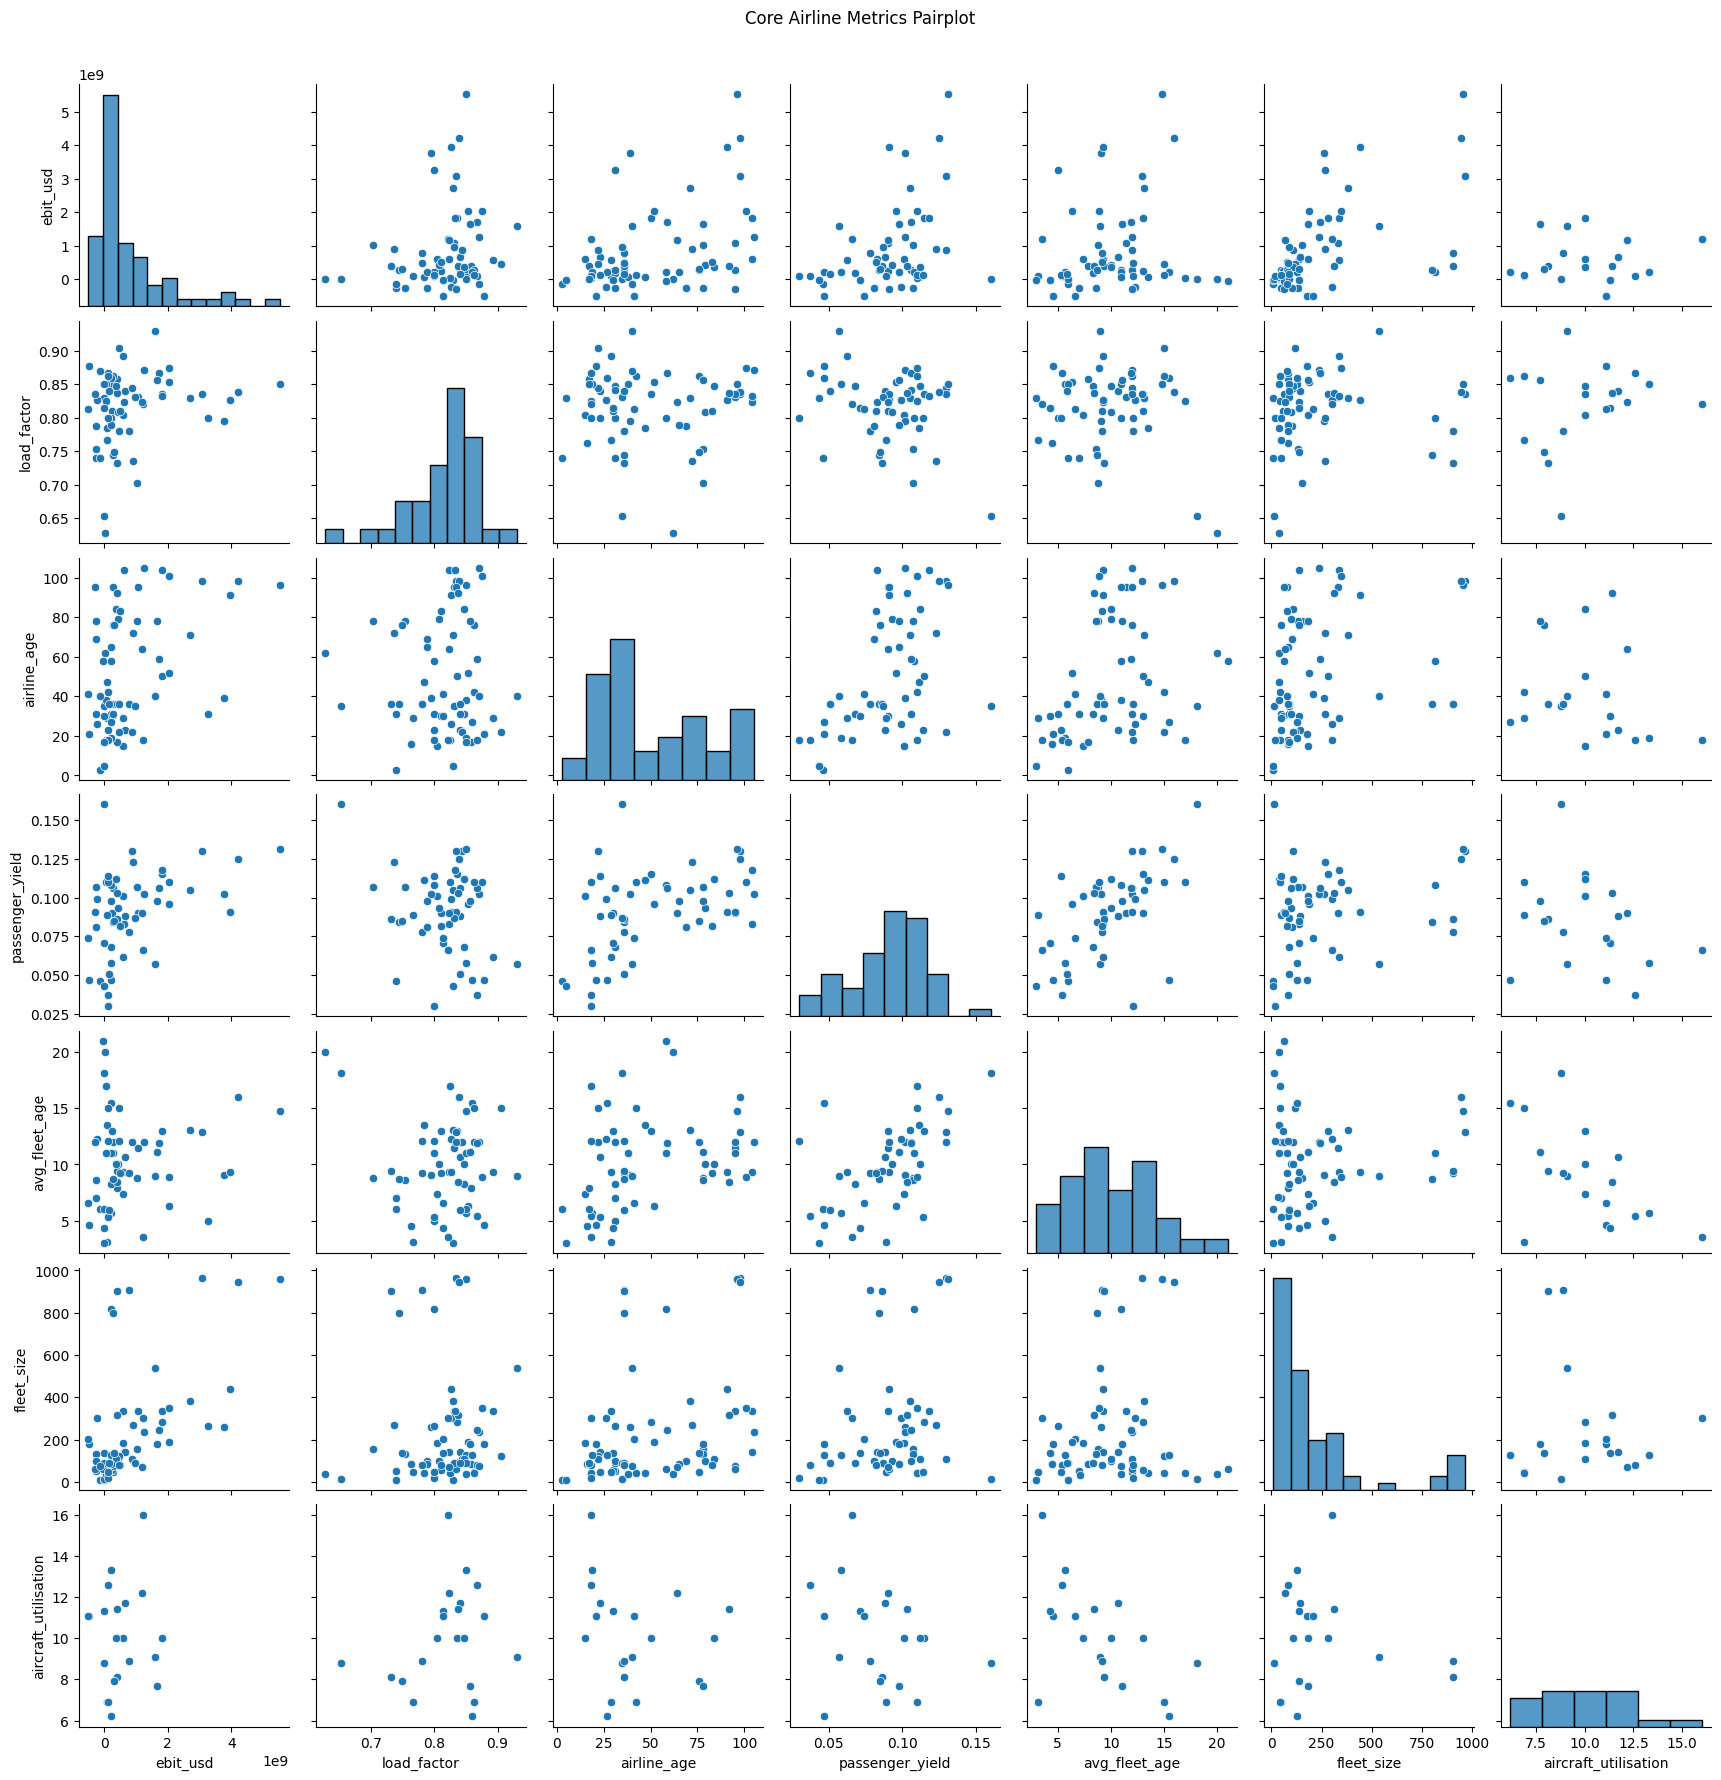

In [17]:
core_cols = ['ebit_usd', 'load_factor', 'airline_age', 'passenger_yield', 
             'avg_fleet_age', 'fleet_size', 'aircraft_utilisation']

sns.pairplot(df[core_cols])
plt.suptitle("Core Airline Metrics Pairplot", y=1.02)
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [19]:
cat_cols = ['iata_code', 'airline_name', 'region', 'functional_currency']

# Convert target to binary: 0 or 1
df['low_cost_carrier'] = df['low_cost_carrier'].map({
    'Y': 1, 'N': 0, 'Yes': 1, 'No': 0, True: 1, False: 0
})

# Drop rows with unmapped values
df = df[df['low_cost_carrier'].isin([0, 1])]

# Label encode categorical columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Features and target
X = df.drop(columns=['low_cost_carrier'])
y = df['low_cost_carrier'].astype(int)

# Impute missing values (if any)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM (Linear)": SVC(kernel='linear'),
    "SVM (RBF)": SVC(kernel='rbf'),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate
print("Model Accuracy Scores (%):\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {accuracy:.2f}%")


Model Accuracy Scores (%):

Logistic Regression: 90.00%
Decision Tree: 80.00%
Random Forest: 95.00%
Gradient Boosting: 85.00%
SVM (Linear): 90.00%
SVM (RBF): 95.00%
K-Nearest Neighbors: 90.00%
Naive Bayes: 90.00%


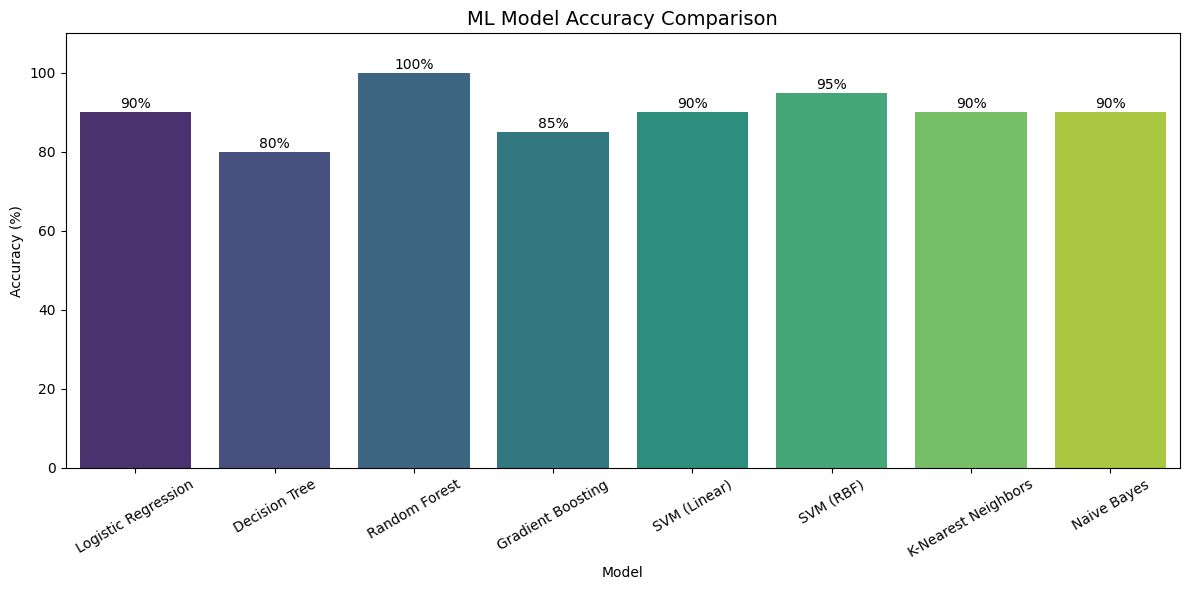

In [22]:
model_names = [
    "Logistic Regression", "Decision Tree", "Random Forest",
    "Gradient Boosting", "SVM (Linear)", "SVM (RBF)",
    "K-Nearest Neighbors", "Naive Bayes"
]

accuracies = [90.00, 80.00, 100.00, 85.00, 90.00, 95.00, 90.00, 90.00]

# Create DataFrame for plotting
accuracy_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy (%)": accuracies
})

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=accuracy_df, x="Model", y="Accuracy (%)", palette="viridis")

# Add accuracy values on top of bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row["Accuracy (%)"] + 1, f'{row["Accuracy (%)"]:.0f}%', ha='center', fontsize=10)

plt.ylim(0, 110)
plt.xticks(rotation=30)
plt.title("ML Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!